# SORA.Earth - EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/projects.csv')
print(df.shape)
df.head()

(100, 8)


,name,budget,co2_reduction,social_impact,duration_months,success,category,region
0,Tree Planting Project 1,5819,32,8,9,1,Tree Planting,Europe
1,Composting Pilot 2,4424,18,7,3,0,Composting,North America
2,Recycling Hub Pilot 3,48118,21,8,12,1,Recycling Hub,Africa
3,Green Building Program 4,51703,50,8,22,1,Green Building,Asia
4,Geothermal Energy Network 5,376472,78,3,48,1,Geothermal Energy,North America


## 1. Статистика

In [2]:
df.describe().round(2)

,budget,co2_reduction,social_impact,duration_months,success
count,100.00,100.00,100.00,100.00,100.00
mean,181824.33,54.56,6.91,22.93,0.74
std,202119.50,23.49,2.04,15.70,0.44
min,3158.00,6.00,2.00,3.00,0.00
25%,32568.75,34.75,5.00,9.75,0.00
50%,98003.50,52.00,7.00,18.50,1.00
75%,281753.75,74.25,8.25,34.00,1.00
max,896897.00,97.00,10.00,58.00,1.00


## 2. Категории

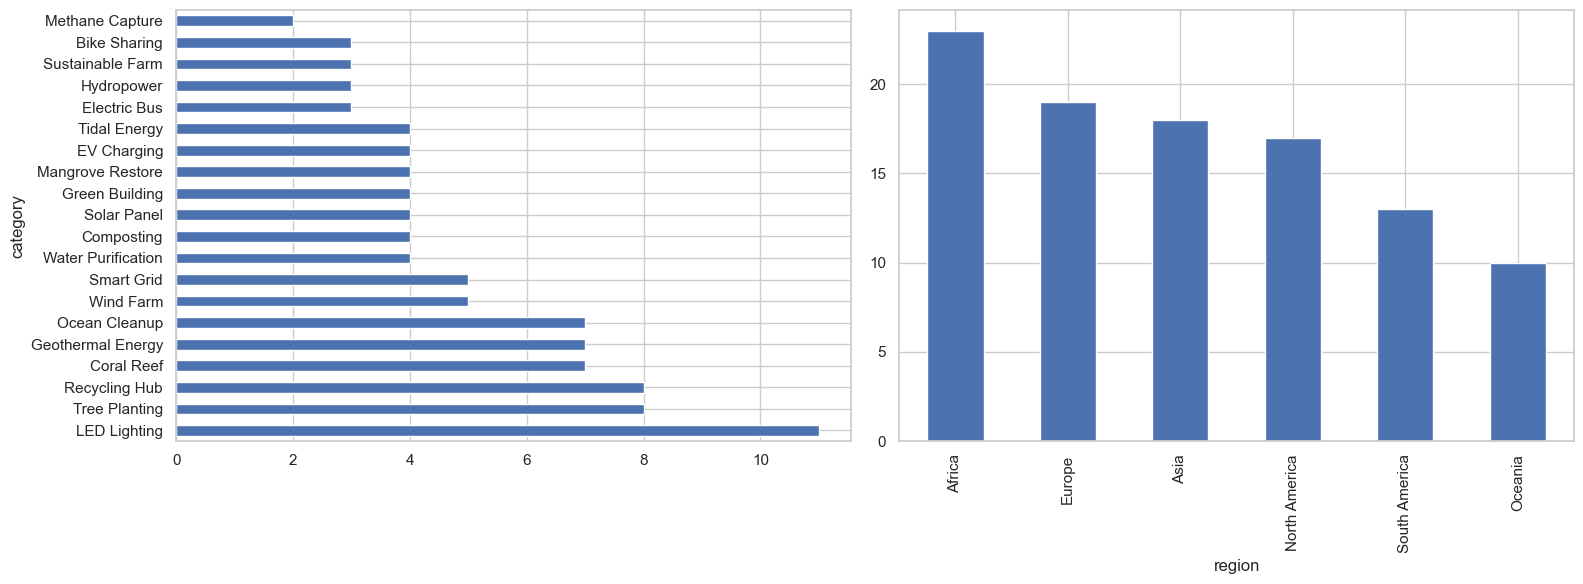

In [3]:
fig,ax=plt.subplots(1,2,figsize=(16,6))
df.category.value_counts().plot.barh(ax=ax[0])
df.region.value_counts().plot.bar(ax=ax[1])
plt.tight_layout()
plt.savefig('../plots/eda_cat.png',dpi=150)
plt.show()

## 3. Распределения

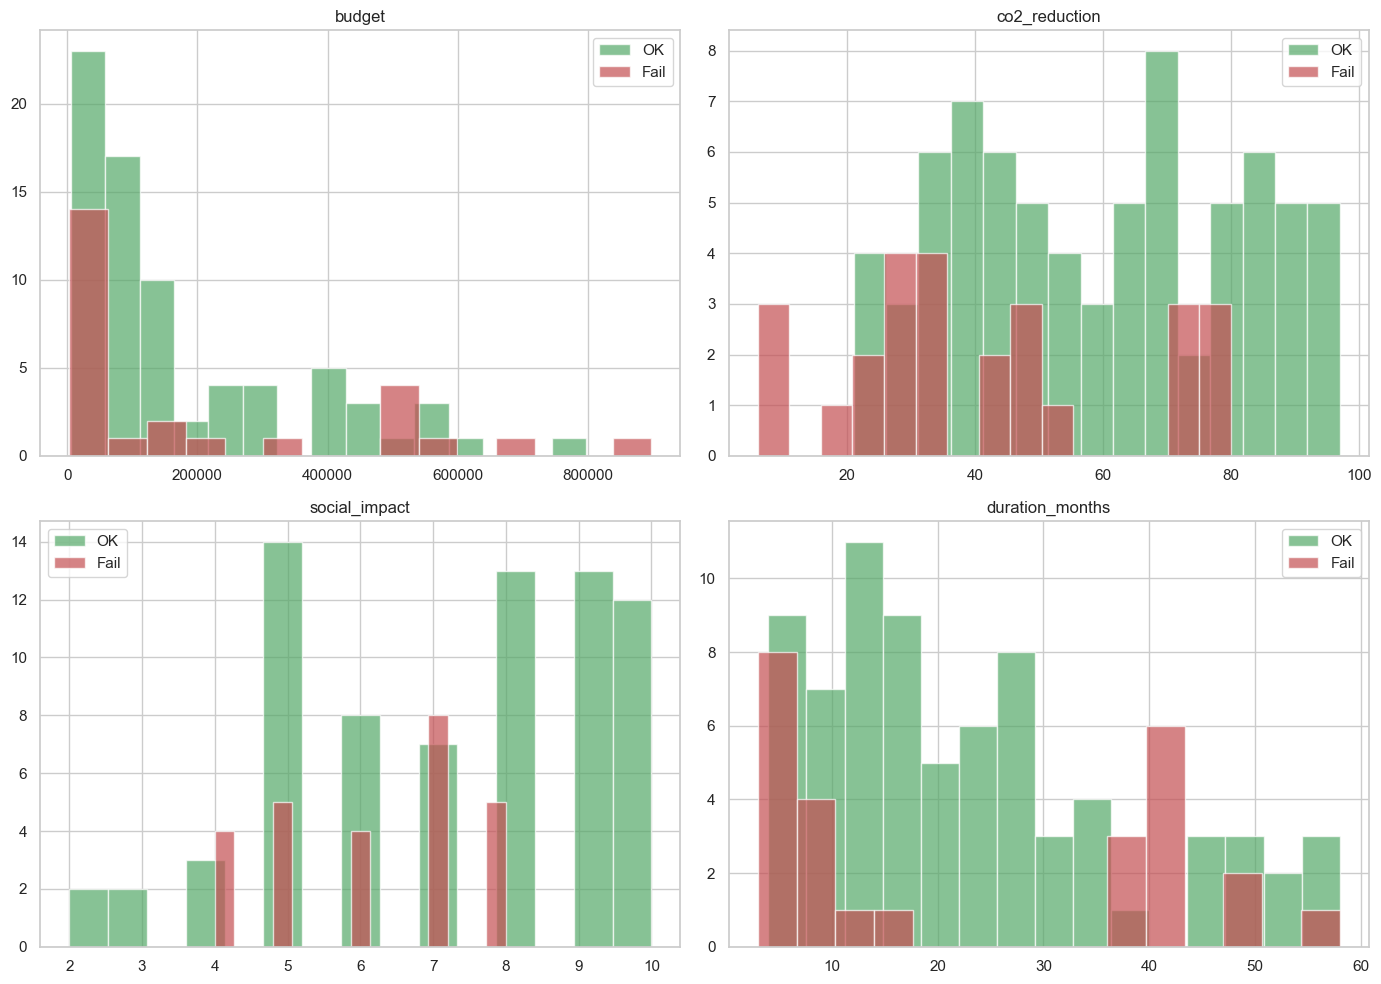

In [4]:
ft=['budget','co2_reduction','social_impact','duration_months']
fig,ax=plt.subplots(2,2,figsize=(14,10))
for a,c2 in zip(ax.flat,ft):
    a.hist(df[df.success==1][c2],bins=15,alpha=.7,label='OK',color='g')
    a.hist(df[df.success==0][c2],bins=15,alpha=.7,label='Fail',color='r')
    a.set_title(c2);a.legend()
plt.tight_layout()
plt.savefig('../plots/eda_dist.png',dpi=150)
plt.show()

## 4. Корреляции

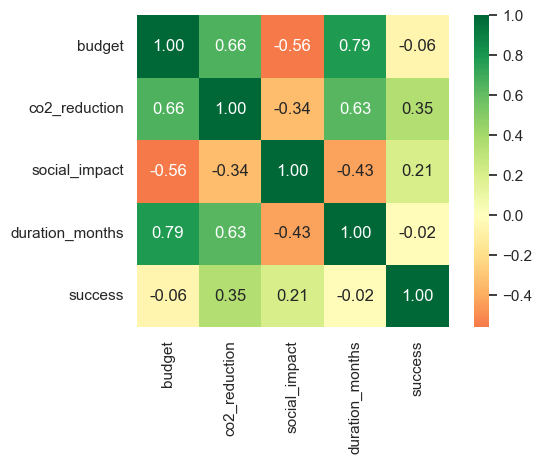

In [5]:
corr=df[ft+['success']].corr()
sns.heatmap(corr,annot=True,cmap='RdYlGn',center=0,fmt='.2f',square=True)
plt.tight_layout()
plt.savefig('../plots/eda_corr.png',dpi=150)
plt.show()

## 5. Boxplots

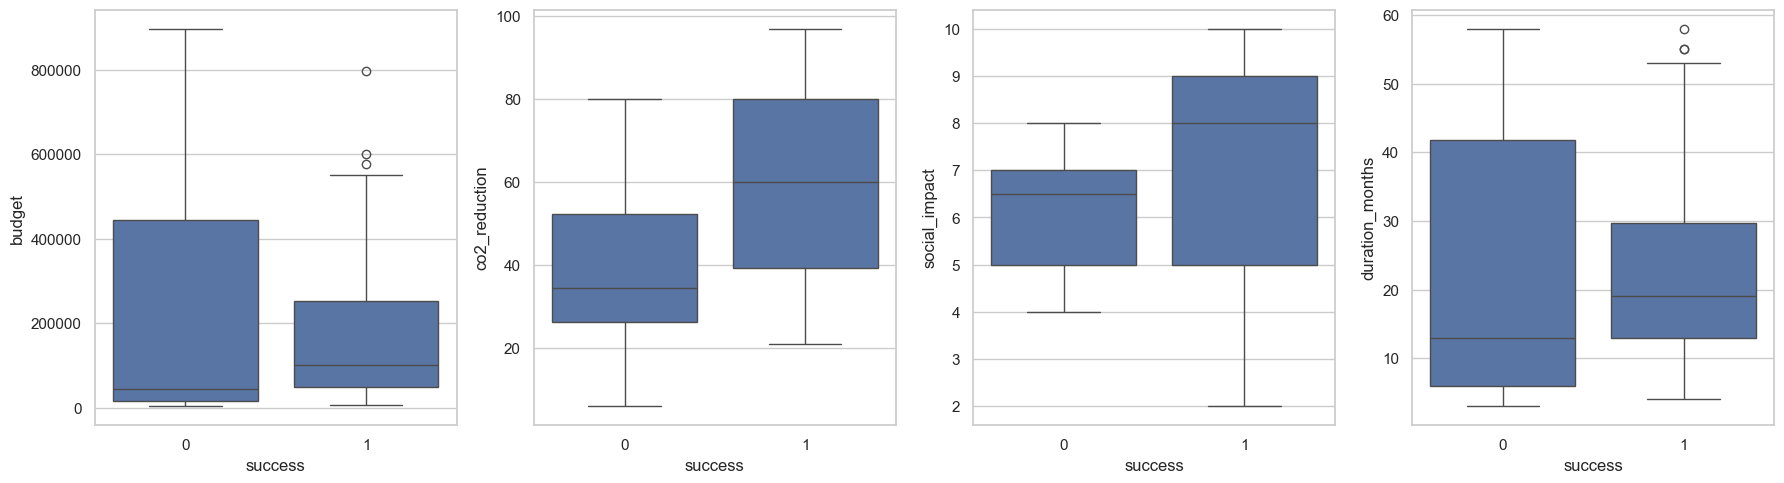

In [6]:
fig,ax=plt.subplots(1,4,figsize=(18,5))
for a,c2 in zip(ax,ft):
    sns.boxplot(data=df,x='success',y=c2,ax=a)
plt.tight_layout()
plt.savefig('../plots/eda_box.png',dpi=150)
plt.show()

## 6. Pairplot

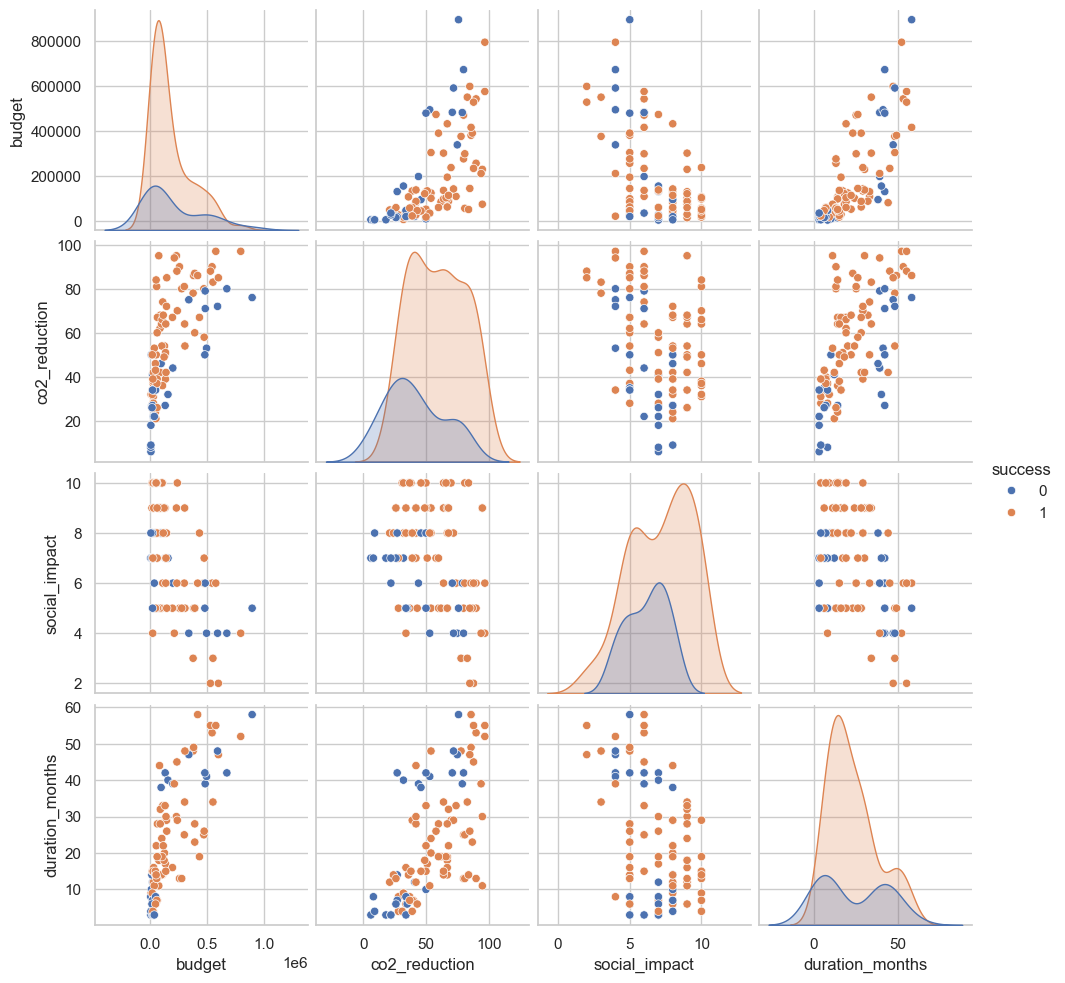

In [7]:
sns.pairplot(df[ft+['success']],hue='success',diag_kind='kde')
plt.savefig('../plots/eda_pair.png',dpi=150)
plt.show()

## 7. Success Rate

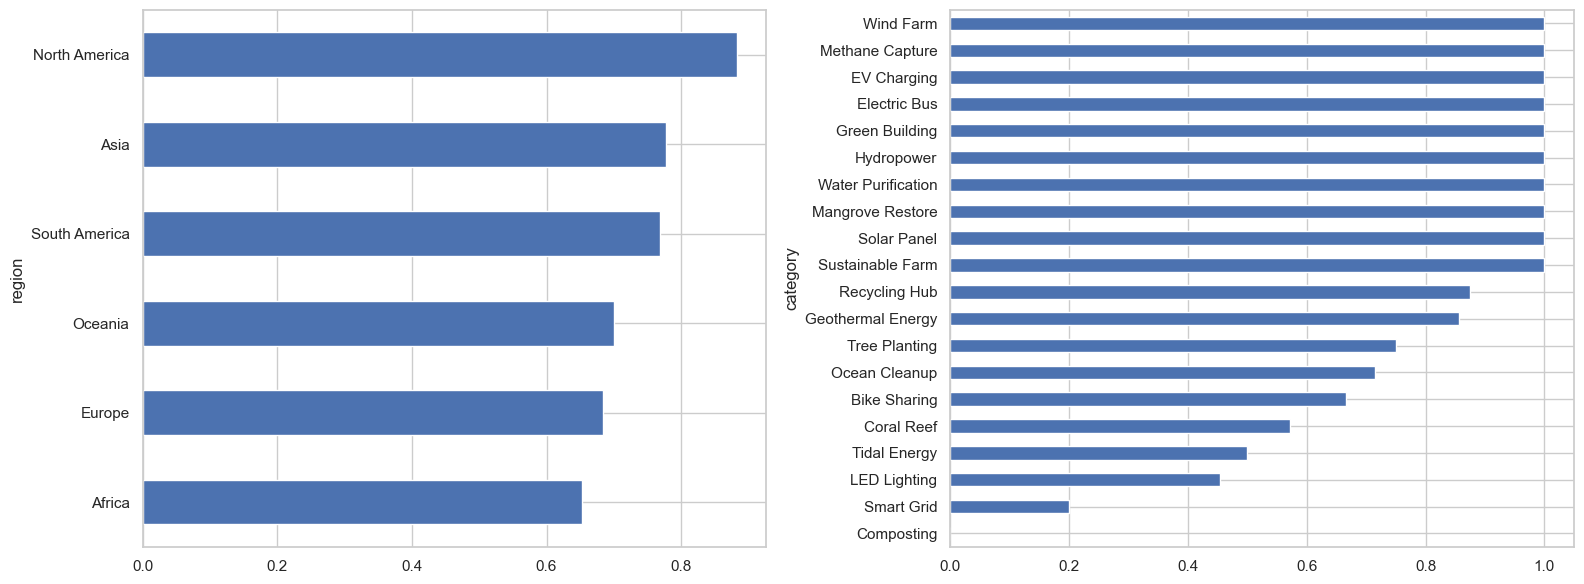

In [8]:
fig,ax=plt.subplots(1,2,figsize=(16,6))
df.groupby('region')['success'].mean().sort_values().plot.barh(ax=ax[0])
df.groupby('category')['success'].mean().sort_values().plot.barh(ax=ax[1])
plt.tight_layout()
plt.savefig('../plots/eda_rates.png',dpi=150)
plt.show()

## 8. Стат. тесты

In [9]:
for c2 in ft:
    t,p=stats.ttest_ind(df[df.success==1][c2],df[df.success==0][c2])
    print(f'{c2:20s} t={t:.3f} p={p:.4f}')

budget               t=-0.618 p=0.5377
co2_reduction        t=3.649 p=0.0004
social_impact        t=2.127 p=0.0359
duration_months      t=-0.171 p=0.8647
